# CS412 - Research Mini-Project
## Bisaya Post-Class Speech and Affective State Recognition Among Computer Science Students

> **Analysis note:** This notebook evaluates both valence and arousal using the same model settings, participant-grouped folds, and fold-local preprocessing as `export_audio_outputs.py`. It uses the existing feature artifact by default for reproducibility. The final cells compare current results against saved exports without overwriting them. Differences are reported explicitly.

**Authors / Group:** CS412 Research Group  
**Dataset:** Bisaya Post-Class Speech and Affect Dataset (40 Participant Audio Samples)  
**Pipeline:** Research Protocol → Natural Speech Collection → Self-Reported Affect → Audio Preprocessing → Acoustic Feature Extraction → Exploratory Analysis → Machine Learning → Evaluation & Interpretation  

---

### Research Objectives & Questions:
- **RQ1:** What affective states do Computer Science students report immediately after their classes?
- **RQ2:** How do post-class affective states vary according to class activity, year level, and class session?
- **RQ3:** What acoustic and prosodic characteristics are exhibited in short Bisaya speech responses across different self-reported affective states?
- **RQ4:** To what extent can machine learning models classify students' self-reported affective states using acoustic and prosodic features extracted from speech responses?
- **RQ5:** Which machine learning model provides the best performance for the collected Bisaya post-class speech dataset?


### Step 1: Environment Setup & Library Imports
Importing necessary libraries for audio processing (`librosa`), data manipulation (`pandas`, `numpy`), data visualization (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`).

In [1]:
import os
import warnings
from pathlib import Path
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import sklearn
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.exceptions import UndefinedMetricWarning

# Hide only known display/undefined-metric noise, not all warnings.
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
warnings.filterwarnings('ignore', message='Passing `palette` without assigning `hue`.*', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)
print(f'Python {platform.python_version()} | scikit-learn {sklearn.__version__} | numpy {np.__version__} | librosa {librosa.__version__}')


Python 3.12.0 | scikit-learn 1.9.1 | numpy 2.5.3 | librosa 0.11.0


### Step 2: Dataset Ingestion & Metadata Sanitization
Loading the collected participant metadata CSV (`bisaya_post_class_speech_metadata.csv`) containing anonymous participant codes, educational contexts, spoken words, self-reported feelings, and 5-point Valence/Arousal ratings.

In [2]:
metadata_path = 'bisaya_post_class_speech_metadata.csv'
df_meta = pd.read_csv(metadata_path)

# Extract integer scores from Valence and Arousal string ratings
df_meta['Valence_Score'] = df_meta['Valence (1-5)'].str.extract(r'^(\d+)').astype(int)
df_meta['Arousal_Score'] = df_meta['Arousal (1-5)'].str.extract(r'^(\d+)').astype(int)

# Bin Valence into 3-class Affect Labels
def map_valence_label(score):
    if score >= 4:
        return 'Pleasant'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Unpleasant'

# Bin Valence into 2-class Binary Affect for ML classification (Pleasant vs Not Pleasant)
df_meta['Valence_Label'] = df_meta['Valence_Score'].apply(map_valence_label)
df_meta['Valence_Binary'] = df_meta['Valence_Score'].apply(lambda s: 'Pleasant' if s >= 4 else 'Not Pleasant')
df_meta['Arousal_Binary'] = df_meta['Arousal_Score'].apply(lambda s: 'High Arousal' if s >= 4 else 'Low/Mod Arousal')

print(f"Dataset loaded: {len(df_meta)} participant observations.")
display(df_meta.head(10))

required = ['Participant Code', 'Year Level', 'Class Activity', 'Session', 'Spoken Word',
            'Self-Reported Feeling', 'Valence (1-5)', 'Arousal (1-5)', 'Audio Filename']
assert not df_meta[required].isna().any().any(), 'Missing required metadata'
assert df_meta['Participant Code'].is_unique, 'Duplicate participant codes'
assert df_meta['Valence_Score'].between(1, 5).all()
assert df_meta['Arousal_Score'].between(1, 5).all()
assert all((Path('Audios') / name).is_file() for name in df_meta['Audio Filename'])


Dataset loaded: 40 participant observations.


,Participant Code,Year Level,Class Activity,Session,Spoken Word,Self-Reported Feeling,Valence (1-5),Arousal (1-5),Audio Filename,Notes,Valence_Score,Arousal_Score,Valence_Label,Valence_Binary,Arousal_Binary
0,Y1-201,1st Year,Lecture,AM,Lingaw,Nalipay,5 — Very Pleasant,3 — Moderate,Y1-201_Y1_AM_Lingaw.wav,NaN,5,3,Pleasant,Pleasant,Low/Mod Arousal
1,Y1-202,1st Year,Lecture,AM,Nadasig,Nalipay,4 — Pleasant,4 — High,Y1-202_Y1_AM_Nadasig.wav,NaN,4,4,Pleasant,Pleasant,High Arousal
2,Y1-203,1st Year,Laboratory,AM,Kapoy,"Ambot, katulgon ko",2 — Unpleasant,2 — Low,Y1-203_Y1_AM_Kapoy_nga_dili.wav,NaN,2,2,Unpleasant,Not Pleasant,Low/Mod Arousal
3,Y1-204,1st Year,Laboratory,AM,Kapoy,Kapoy,3 — Neutral,2 — Low,Y1-204_Y1_AM_Kapoy.wav,NaN,3,2,Neutral,Not Pleasant,Low/Mod Arousal
4,Y1-205,1st Year,Quiz,AM,Kapoy,Kapoy,3 — Neutral,3 — Moderate,Y1-205_Y1_AM_Kapoy.wav,NaN,3,3,Neutral,Not Pleasant,Low/Mod Arousal
5,Y1-206,1st Year,Quiz,AM,Malas,Kapoy,2 — Unpleasant,2 — Low,Y1-206_Y1_AM_Malas.wav,NaN,2,2,Unpleasant,Not Pleasant,Low/Mod Arousal
6,Y1-207,1st Year,Quiz,AM,Kapoy,Grabe kapoy,3 — Neutral,3 — Moderate,Y1-207_Y1_AM_Kapoy.wav,NaN,3,3,Neutral,Not Pleasant,Low/Mod Arousal
7,Y1-208,1st Year,Quiz,AM,Kapoya,Overwhelmed,3 — Neutral,4 — High,Y1-208_Y1_AM_Kapoya.wav,NaN,3,4,Neutral,Not Pleasant,High Arousal
8,Y1-209,1st Year,Laboratory,AM,Lingaw,Lingaw nga dala kapoy,4 — Pleasant,4 — High,Y1-209_Y1_AM_Lingaw_nga_kapoy.wav,NaN,4,4,Pleasant,Pleasant,High Arousal
9,Y1-210,1st Year,Quiz,AM,Kapoy,Kapoy,3 — Neutral,3 — Moderate,Y1-210_Y1_AM_Kapoy.wav,NaN,3,3,Neutral,Not Pleasant,Low/Mod Arousal


### Step 3: Exploratory Data Analysis (EDA) — Addressing RQ1 & RQ2
Investigating the distribution of self-reported affective states, valence/arousal ratings, and educational contexts (Class Activity and Session).

C:\Users\Mark Limpahan\AppData\Local\Temp\ipykernel_17296\437738438.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_meta, x='Valence (1-5)', palette='viridis', ax=axes[0, 0])
C:\Users\Mark Limpahan\AppData\Local\Temp\ipykernel_17296\437738438.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_meta, x='Arousal (1-5)', palette='magma', ax=axes[0, 1])


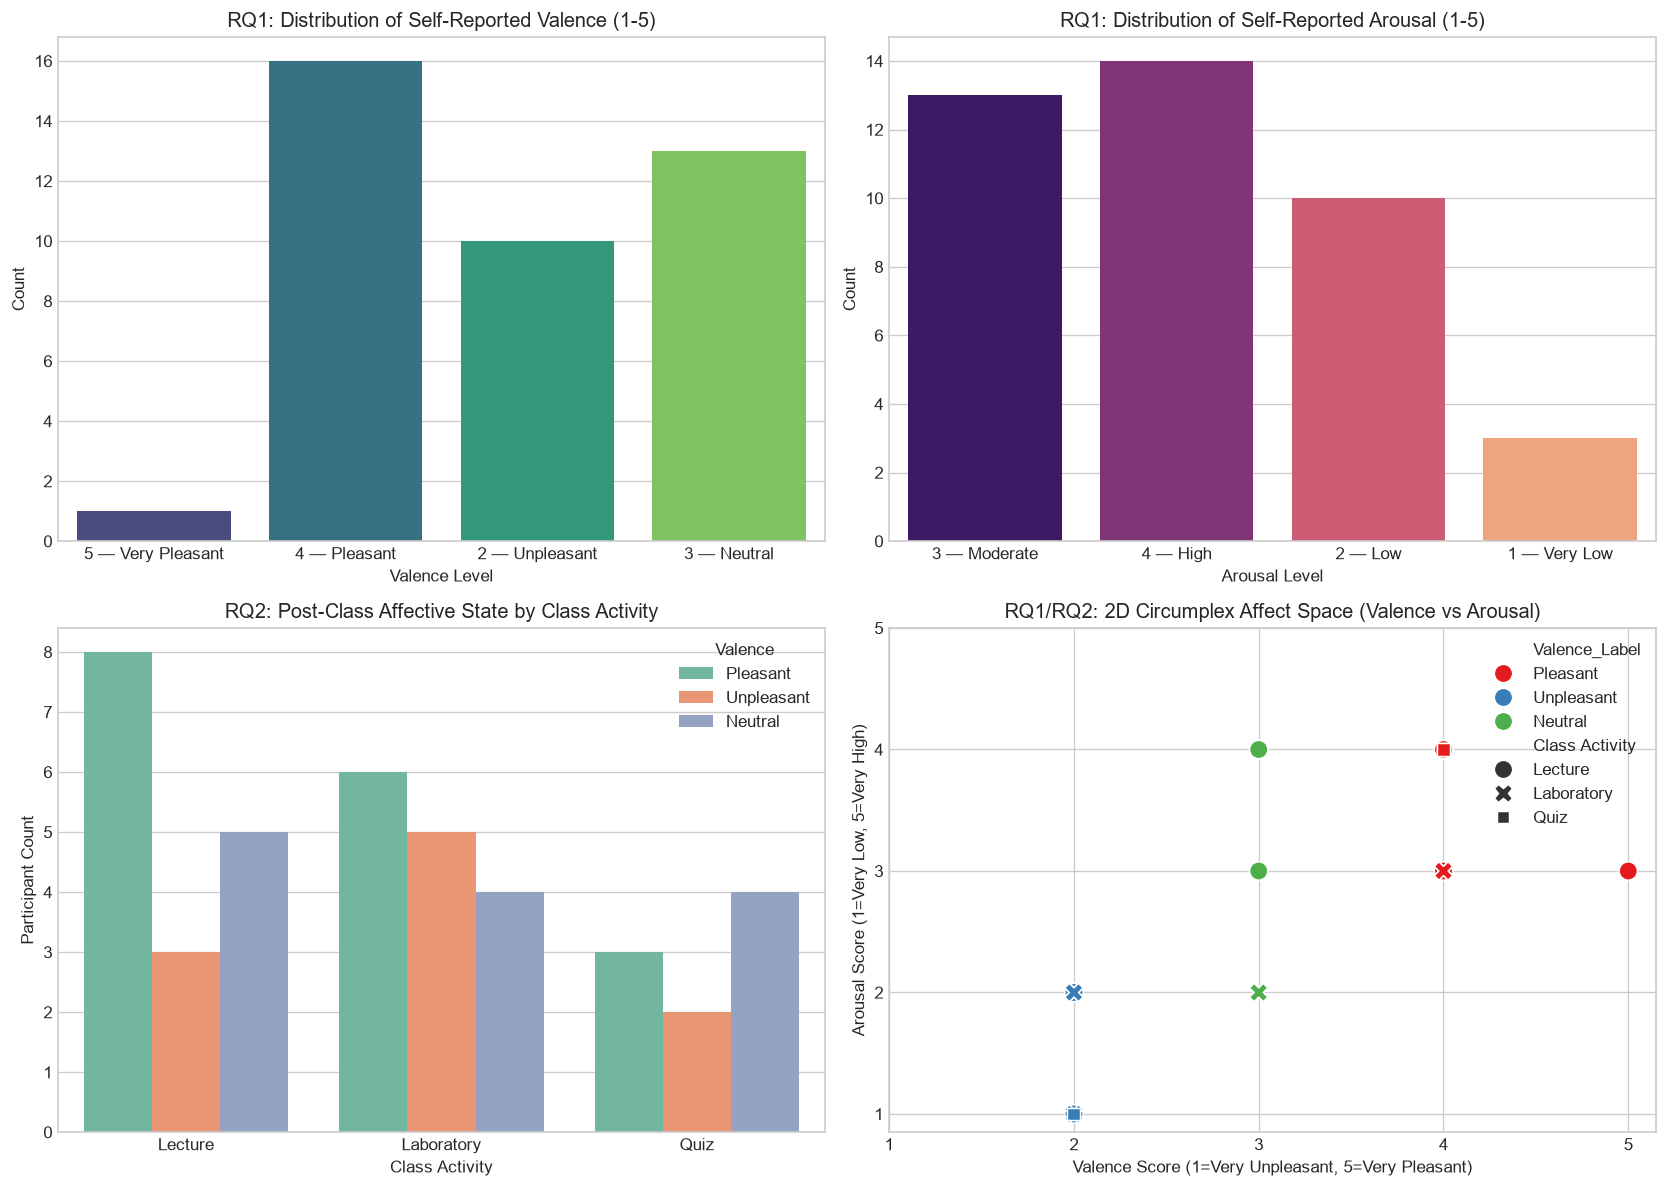

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Valence Score Distribution
sns.countplot(data=df_meta, x='Valence (1-5)', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('RQ1: Distribution of Self-Reported Valence (1-5)')
axes[0, 0].set_xlabel('Valence Level')
axes[0, 0].set_ylabel('Count')

# 2. Arousal Score Distribution
sns.countplot(data=df_meta, x='Arousal (1-5)', palette='magma', ax=axes[0, 1])
axes[0, 1].set_title('RQ1: Distribution of Self-Reported Arousal (1-5)')
axes[0, 1].set_xlabel('Arousal Level')
axes[0, 1].set_ylabel('Count')

# 3. Class Activity vs Valence Label
sns.countplot(data=df_meta, x='Class Activity', hue='Valence_Label', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('RQ2: Post-Class Affective State by Class Activity')
axes[1, 0].set_xlabel('Class Activity')
axes[1, 0].set_ylabel('Participant Count')
axes[1, 0].legend(title='Valence')

# 4. 2D Valence-Arousal Space Scatter Plot
sns.scatterplot(data=df_meta, x='Valence_Score', y='Arousal_Score', hue='Valence_Label', 
                style='Class Activity', s=120, palette='Set1', ax=axes[1, 1])
axes[1, 1].set_title('RQ1/RQ2: 2D Circumplex Affect Space (Valence vs Arousal)')
axes[1, 1].set_xlabel('Valence Score (1=Very Unpleasant, 5=Very Pleasant)')
axes[1, 1].set_ylabel('Arousal Score (1=Very Low, 5=Very High)')
axes[1, 1].set_xticks([1, 2, 3, 4, 5])
axes[1, 1].set_yticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()


### Step 4: Spoken Word Frequency & Affective Ambiguity Analysis
Analyzing which Bisaya words were selected across different self-reported affect levels.

C:\Users\Mark Limpahan\AppData\Local\Temp\ipykernel_17296\214685819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts.index, y=word_counts.values, palette='Blues_r')


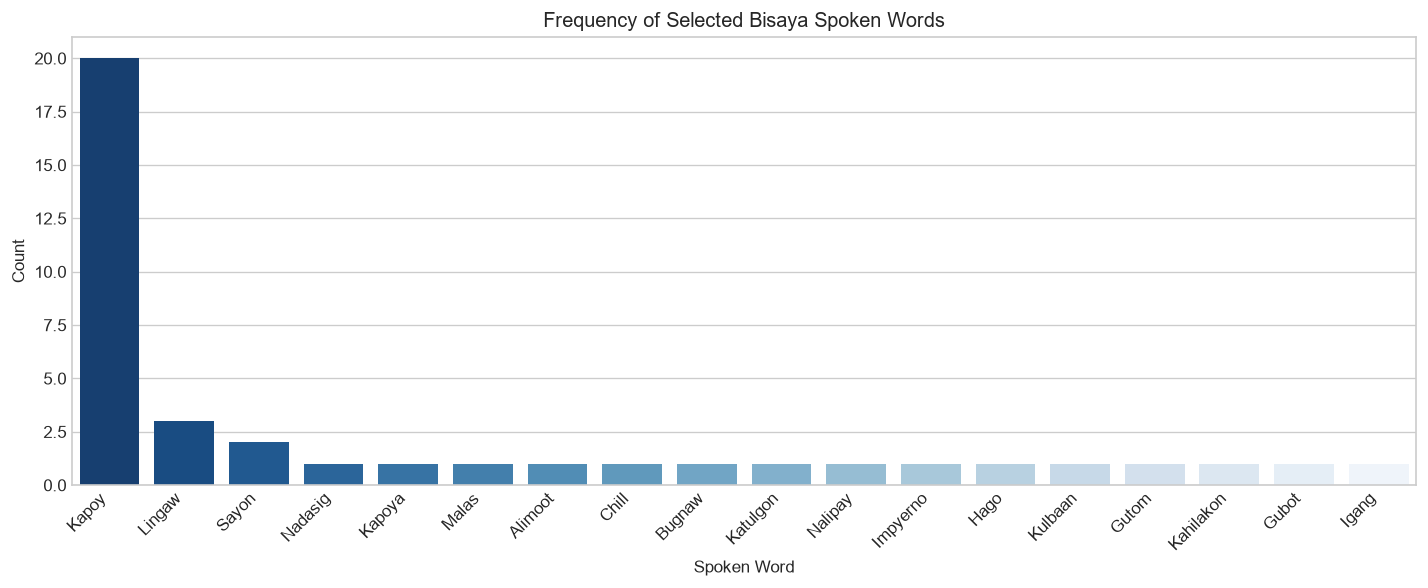

--- Cross-tabulation: Spoken Word vs Self-Reported Valence ---


Valence_Label,Neutral,Pleasant,Unpleasant
Spoken Word,,,
Kapoy,9,8,3
Lingaw,0,3,0
Sayon,0,2,0
Bugnaw,0,1,0
Nalipay,0,1,0
Chill,0,1,0
Nadasig,0,1,0
Alimoot,0,0,1
Gutom,0,0,1


In [4]:
plt.figure(figsize=(12, 5))
word_counts = df_meta['Spoken Word'].value_counts()
sns.barplot(x=word_counts.index, y=word_counts.values, palette='Blues_r')
plt.title('Frequency of Selected Bisaya Spoken Words')
plt.xlabel('Spoken Word')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Cross-tabulation of Spoken Word vs Valence Label
ct_word_val = pd.crosstab(df_meta['Spoken Word'], df_meta['Valence_Label'])
print("--- Cross-tabulation: Spoken Word vs Self-Reported Valence ---")
display(ct_word_val.sort_values(by='Pleasant', ascending=False).head(10))


### Step 5: Audio Signal Preprocessing & Waveform/Spectrogram Inspection
Visualizing sample raw speech recordings from different affective categories.

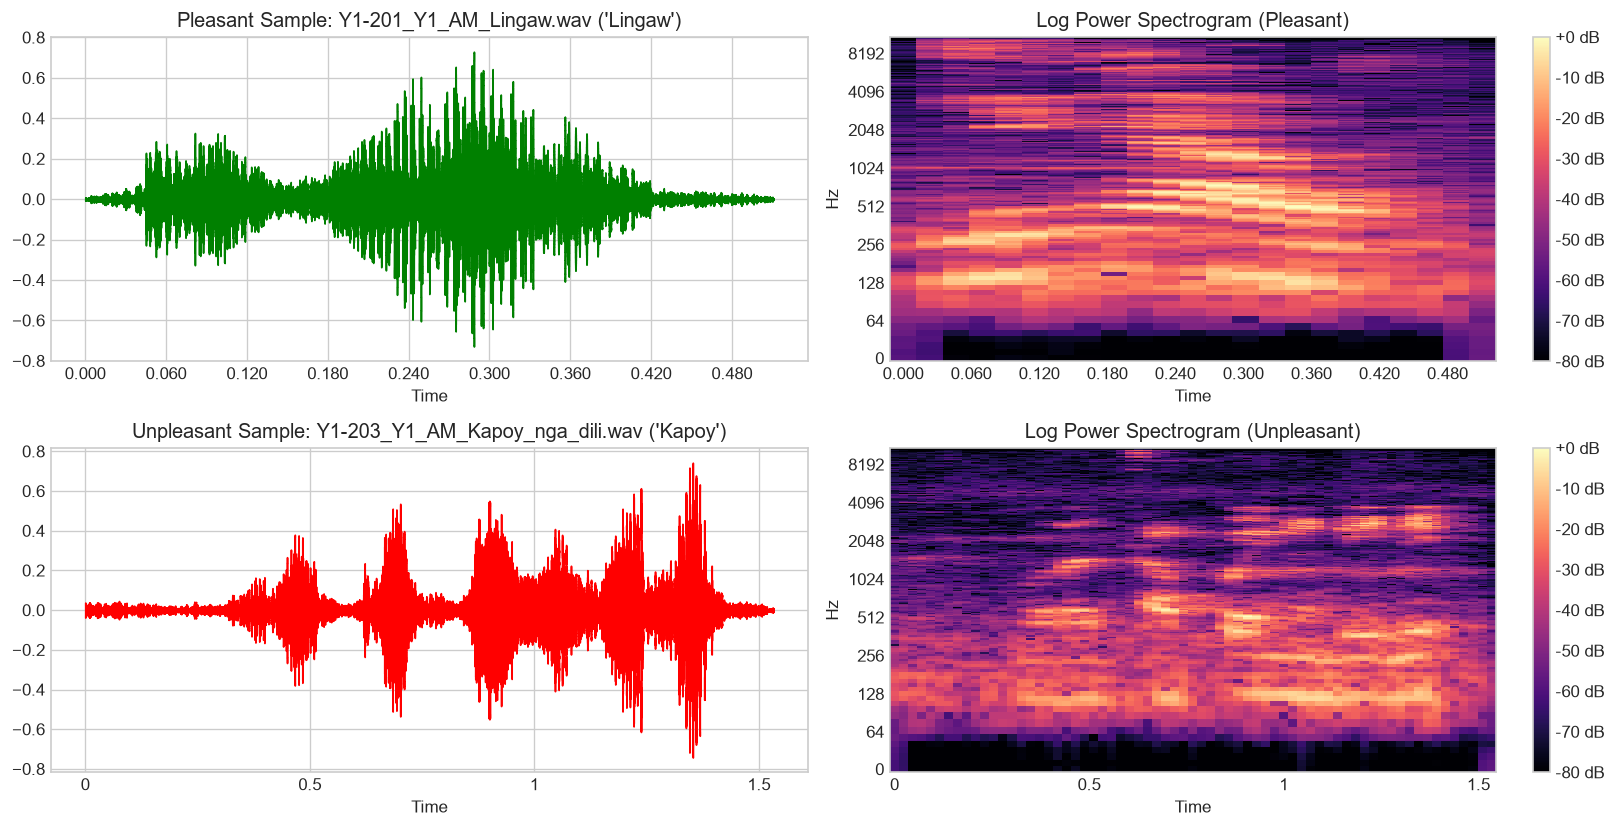

In [5]:
sample_pleasant = df_meta[df_meta['Valence_Label'] == 'Pleasant'].iloc[0]
sample_unpleasant = df_meta[df_meta['Valence_Label'] == 'Unpleasant'].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# Pleasant Sample Waveform & Spectrogram
y_p, sr_p = librosa.load(os.path.join('Audios', sample_pleasant['Audio Filename'].strip()), sr=22050)
y_p_trim, _ = librosa.effects.trim(y_p, top_db=25)
librosa.display.waveshow(y_p_trim, sr=sr_p, ax=axes[0, 0], color='green')
axes[0, 0].set_title(f"Pleasant Sample: {sample_pleasant['Audio Filename']} ('{sample_pleasant['Spoken Word']}')")

S_p = librosa.amplitude_to_db(np.abs(librosa.stft(y_p_trim)), ref=np.max)
img1 = librosa.display.specshow(S_p, sr=sr_p, x_axis='time', y_axis='log', ax=axes[0, 1])
axes[0, 1].set_title("Log Power Spectrogram (Pleasant)")
fig.colorbar(img1, ax=axes[0, 1], format="%+2.0f dB")

# Unpleasant Sample Waveform & Spectrogram
y_u, sr_u = librosa.load(os.path.join('Audios', sample_unpleasant['Audio Filename'].strip()), sr=22050)
y_u_trim, _ = librosa.effects.trim(y_u, top_db=25)
librosa.display.waveshow(y_u_trim, sr=sr_u, ax=axes[1, 0], color='red')
axes[1, 0].set_title(f"Unpleasant Sample: {sample_unpleasant['Audio Filename']} ('{sample_unpleasant['Spoken Word']}')")

S_u = librosa.amplitude_to_db(np.abs(librosa.stft(y_u_trim)), ref=np.max)
img2 = librosa.display.specshow(S_u, sr=sr_u, x_axis='time', y_axis='log', ax=axes[1, 1])
axes[1, 1].set_title("Log Power Spectrogram (Unpleasant)")
fig.colorbar(img2, ax=axes[1, 1], format="%+2.0f dB")

plt.tight_layout()
plt.show()


### Step 6: Acoustic & Prosodic Feature Extraction — Addressing RQ3
Extracting 94 acoustic features per recording:
1. **Prosodic Features:** Pitch (F0 mean, std, max, min via YIN), RMS Energy (mean, std, max), Zero-Crossing Rate (mean, std), Duration.
2. **Spectral Features:** Spectral Centroid, Bandwidth, Rolloff (mean, std).
3. **Timbral Features:** 13 MFCCs, 13 Delta MFCCs, 13 Delta-Delta MFCCs (means and standard deviations).

By default, load the existing feature CSV to reproduce the export evaluation. Set `REEXTRACT_FEATURES = True` to regenerate and save features from WAV files. Metadata joins use participant codes rather than row position.

In [6]:
def extract_audio_features(audio_path, sr_target=22050):
    y, sr = librosa.load(audio_path, sr=sr_target)
    # Silence trimming
    y_trimmed, _ = librosa.effects.trim(y, top_db=25)
    if len(y_trimmed) == 0:
        y_trimmed = y
        
    duration = librosa.get_duration(y=y_trimmed, sr=sr)
    
    # 1. Pitch / Fundamental Frequency (F0) using YIN
    f0 = librosa.yin(y_trimmed, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'), sr=sr)
    f0_valid = f0[(f0 >= 65) & (f0 <= 500)]
    if len(f0_valid) > 0:
        f0_mean = float(np.mean(f0_valid))
        f0_std = float(np.std(f0_valid))
        f0_max = float(np.max(f0_valid))
        f0_min = float(np.min(f0_valid))
    else:
        f0_mean, f0_std, f0_max, f0_min = 0.0, 0.0, 0.0, 0.0

    # 2. RMS Energy
    rms = librosa.feature.rms(y=y_trimmed)[0]
    rms_mean, rms_std, rms_max = float(np.mean(rms)), float(np.std(rms)), float(np.max(rms))

    # 3. Zero Crossing Rate (ZCR)
    zcr = librosa.feature.zero_crossing_rate(y=y_trimmed)[0]
    zcr_mean, zcr_std = float(np.mean(zcr)), float(np.std(zcr))

    # 4. Spectral Descriptors
    sc = librosa.feature.spectral_centroid(y=y_trimmed, sr=sr)[0]
    sc_mean, sc_std = float(np.mean(sc)), float(np.std(sc))
    
    sb = librosa.feature.spectral_bandwidth(y=y_trimmed, sr=sr)[0]
    sb_mean, sb_std = float(np.mean(sb)), float(np.std(sb))
    
    sro = librosa.feature.spectral_rolloff(y=y_trimmed, sr=sr)[0]
    sro_mean, sro_std = float(np.mean(sro)), float(np.std(sro))

    # 5. MFCCs (13), Deltas, Delta-Deltas
    mfcc = librosa.feature.mfcc(y=y_trimmed, sr=sr, n_mfcc=13)
    mfcc_d = librosa.feature.delta(mfcc)
    mfcc_dd = librosa.feature.delta(mfcc, order=2)

    feats = {
        'duration': duration,
        'f0_mean': f0_mean, 'f0_std': f0_std, 'f0_max': f0_max, 'f0_min': f0_min,
        'rms_mean': rms_mean, 'rms_std': rms_std, 'rms_max': rms_max,
        'zcr_mean': zcr_mean, 'zcr_std': zcr_std,
        'sc_mean': sc_mean, 'sc_std': sc_std,
        'sb_mean': sb_mean, 'sb_std': sb_std,
        'sro_mean': sro_mean, 'sro_std': sro_std,
    }

    for i in range(13):
        feats[f'mfcc_{i+1}_mean'] = float(np.mean(mfcc[i]))
        feats[f'mfcc_{i+1}_std'] = float(np.std(mfcc[i]))
        feats[f'mfcc_delta_{i+1}_mean'] = float(np.mean(mfcc_d[i]))
        feats[f'mfcc_delta_{i+1}_std'] = float(np.std(mfcc_d[i]))
        feats[f'mfcc_delta2_{i+1}_mean'] = float(np.mean(mfcc_dd[i]))
        feats[f'mfcc_delta2_{i+1}_std'] = float(np.std(mfcc_dd[i]))

    return feats

# Preserve the current feature artifact unless regeneration is explicitly enabled.
REEXTRACT_FEATURES = False
from inference.feature_extractor import get_feature_names
feature_cols = get_feature_names()
feature_path = Path('bisaya_extracted_features.csv')
if REEXTRACT_FEATURES:
    feature_rows = []
    for _, row in df_meta.iterrows():
        values = extract_audio_features(str(Path('Audios') / row['Audio Filename']))
        feature_rows.append({'Participant Code': row['Participant Code'], **values})
    feature_block = pd.DataFrame(feature_rows)
else:
    cached = pd.read_csv(feature_path)
    feature_block = cached[['Participant Code', *feature_cols]].copy()
    assert set(feature_block['Participant Code']) == set(df_meta['Participant Code'])

df_full = df_meta.merge(feature_block, on='Participant Code', how='left', validate='one_to_one')
df_feats = df_full[feature_cols].copy()
assert len(feature_cols) == 94
assert np.isfinite(df_feats.to_numpy()).all(), 'Missing or non-finite acoustic features'
if REEXTRACT_FEATURES:
    df_full.to_csv(feature_path, index=False)
print(f'{"Regenerated" if REEXTRACT_FEATURES else "Loaded"} {len(df_full)} rows and {len(feature_cols)} acoustic features.')
print('Features joined by Participant Code; context excluded from predictors.')


Loaded 40 rows and 94 acoustic features.
Features joined by Participant Code; context excluded from predictors.


### Step 7: Acoustic Feature Comparison across Affective States — RQ3 Analysis
Examining how prosodic and spectral features differ across self-reported Valence and Arousal classes.

C:\Users\Mark Limpahan\AppData\Local\Temp\ipykernel_17296\479186530.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full, x='Valence_Label', y='f0_mean', palette='Set2', ax=axes[0, 0])
C:\Users\Mark Limpahan\AppData\Local\Temp\ipykernel_17296\479186530.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full, x='Valence_Label', y='rms_mean', palette='Set2', ax=axes[0, 1])
C:\Users\Mark Limpahan\AppData\Local\Temp\ipykernel_17296\479186530.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full, x='Arousal_Binary

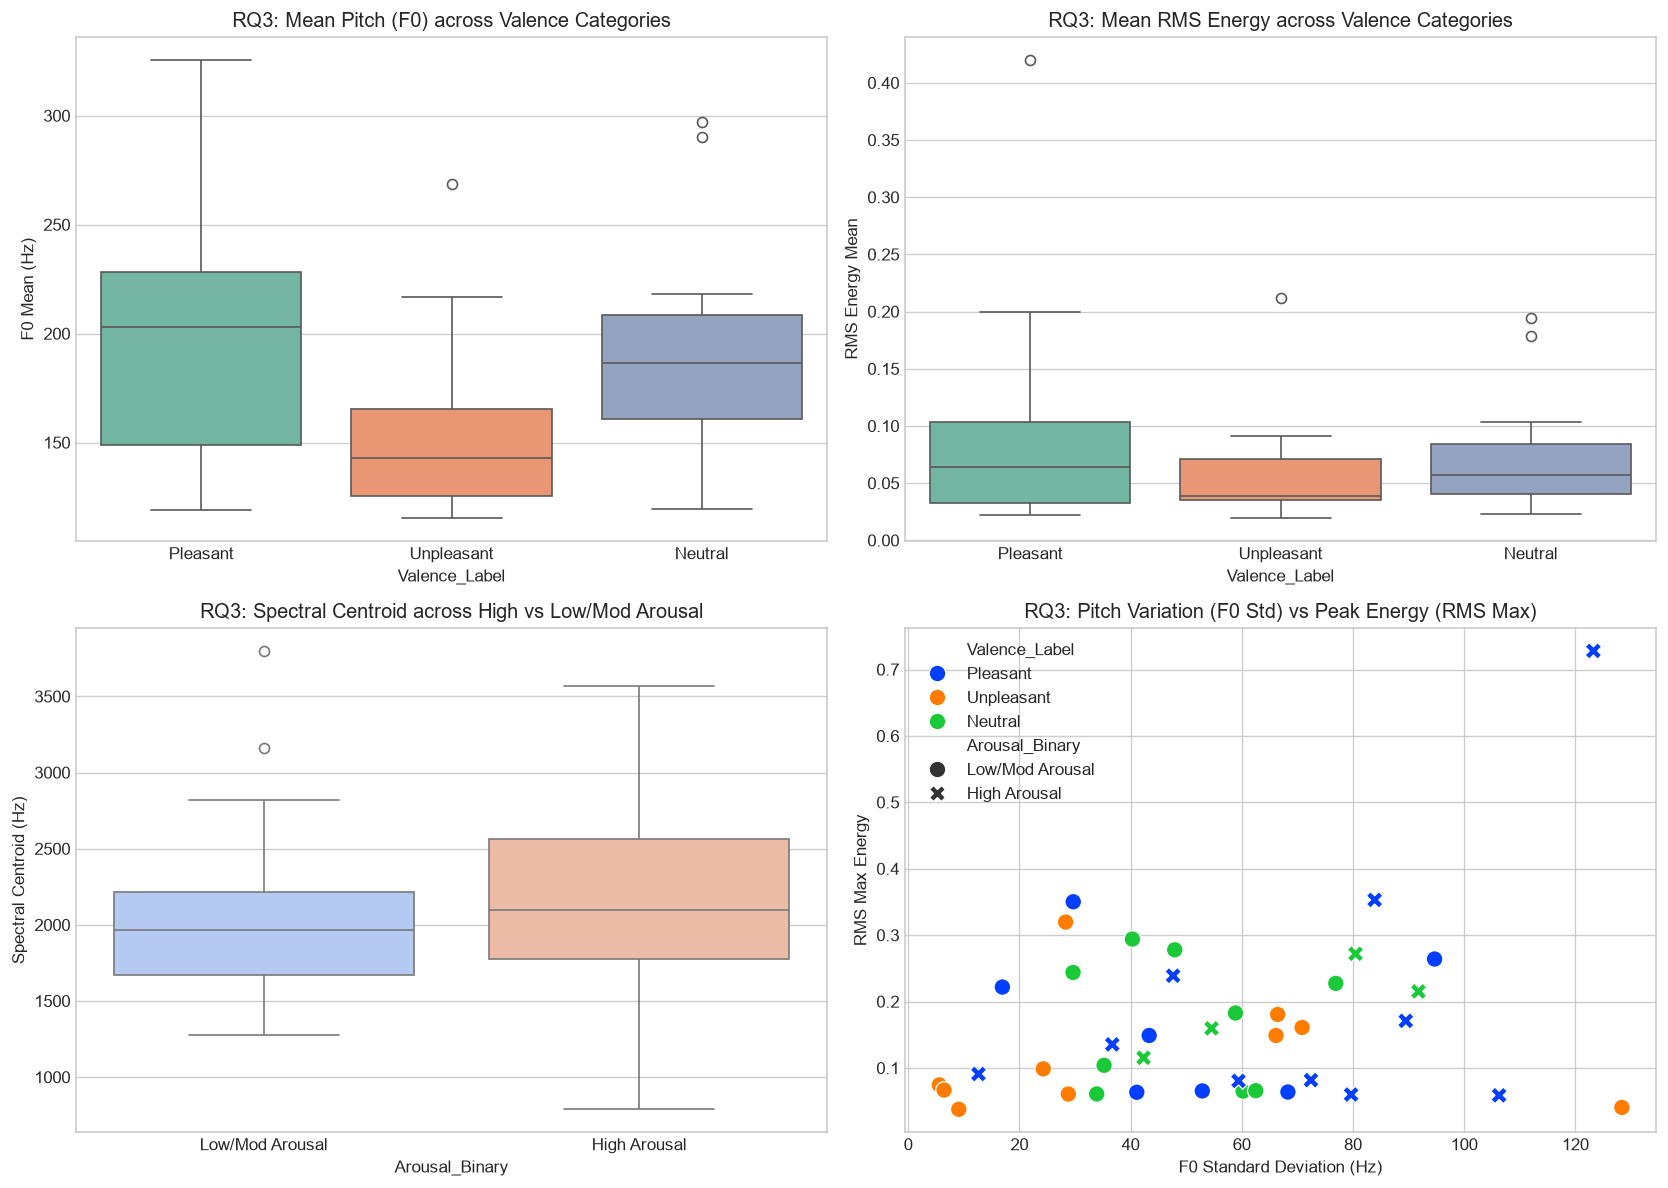

--- Acoustic Summary Statistics by Valence Label ---


,f0_mean,f0_std,rms_mean,sc_mean,zcr_mean
Valence_Label,,,,,
Neutral,190.058372,54.974973,0.075691,1886.978029,0.086066
Pleasant,200.163500,62.254596,0.091072,2210.357139,0.117283
Unpleasant,158.880479,43.435645,0.062555,2155.350148,0.103169


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Pitch Mean (F0) by Valence
sns.boxplot(data=df_full, x='Valence_Label', y='f0_mean', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('RQ3: Mean Pitch (F0) across Valence Categories')
axes[0, 0].set_ylabel('F0 Mean (Hz)')

# 2. RMS Energy Mean by Valence
sns.boxplot(data=df_full, x='Valence_Label', y='rms_mean', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('RQ3: Mean RMS Energy across Valence Categories')
axes[0, 1].set_ylabel('RMS Energy Mean')

# 3. Spectral Centroid by Arousal
sns.boxplot(data=df_full, x='Arousal_Binary', y='sc_mean', palette='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('RQ3: Spectral Centroid across High vs Low/Mod Arousal')
axes[1, 0].set_ylabel('Spectral Centroid (Hz)')

# 4. Pitch Std (Prosodic Variability) vs RMS Max
sns.scatterplot(data=df_full, x='f0_std', y='rms_max', hue='Valence_Label', style='Arousal_Binary', s=100, palette='bright', ax=axes[1, 1])
axes[1, 1].set_title('RQ3: Pitch Variation (F0 Std) vs Peak Energy (RMS Max)')
axes[1, 1].set_xlabel('F0 Standard Deviation (Hz)')
axes[1, 1].set_ylabel('RMS Max Energy')

plt.tight_layout()
plt.show()

print("--- Acoustic Summary Statistics by Valence Label ---")
display(df_full.groupby('Valence_Label')[['f0_mean', 'f0_std', 'rms_mean', 'sc_mean', 'zcr_mean']].mean())


### Step 8: Same-word analysis (Section XVII)
Compare the exact metadata label **Kapoy** across independently reported valence groups. Different labels such as Kapoya are excluded, matching the export script. This is a descriptive comparison, not evidence of validated classification within one word.

Total 'Kapoy' responses in dataset: 20


C:\Users\Mark Limpahan\AppData\Local\Temp\ipykernel_17296\661315150.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_kapoy, x='Valence_Binary', y='f0_mean', palette='husl', ax=axes[0])
C:\Users\Mark Limpahan\AppData\Local\Temp\ipykernel_17296\661315150.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_kapoy, x='Valence_Binary', y='rms_mean', palette='husl', ax=axes[1])
C:\Users\Mark Limpahan\AppData\Local\Temp\ipykernel_17296\661315150.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_kapoy, x='Valence_Binary

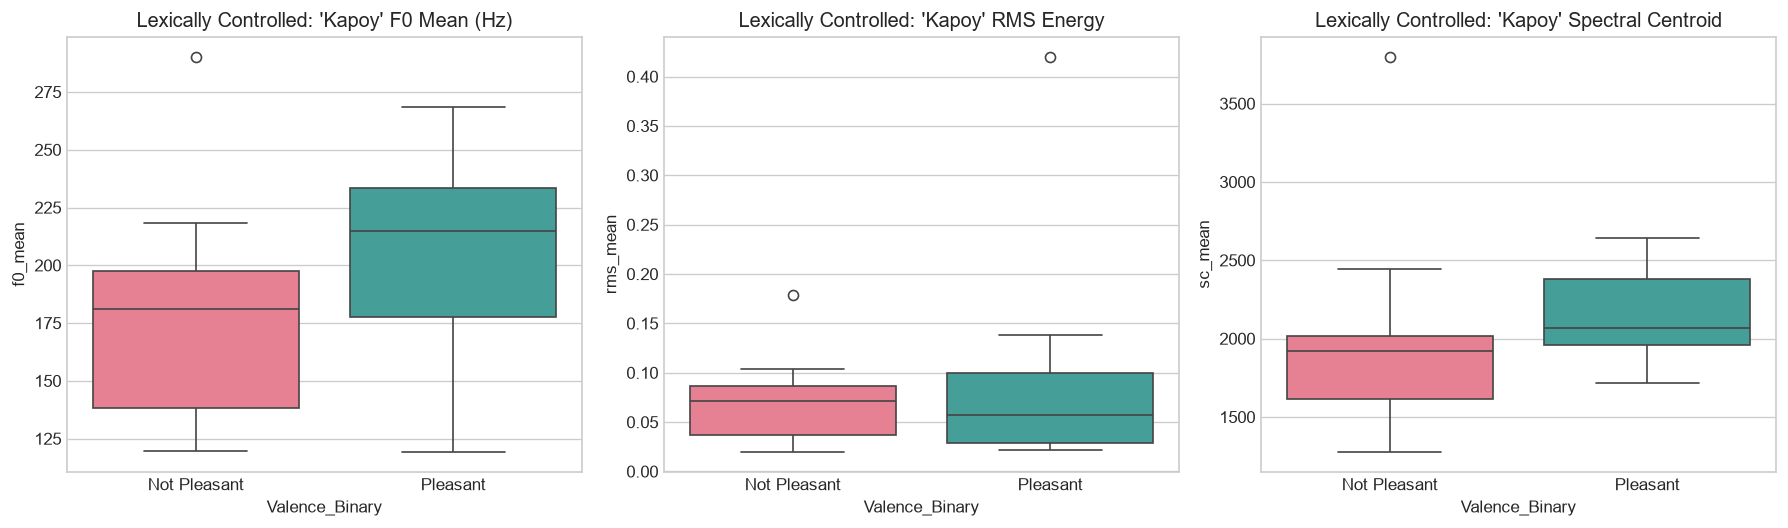

--- Lexically Controlled 'Kapoy' Means ---


,f0_mean,f0_std,rms_mean,sc_mean
Valence_Binary,,,,
Not Pleasant,178.593580,50.600080,0.070715,1993.246189
Pleasant,201.921821,73.386637,0.104399,2150.065518


In [8]:
df_kapoy = df_full[df_full['Spoken Word'].eq('Kapoy')]

print(f"Total 'Kapoy' responses in dataset: {len(df_kapoy)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.boxplot(data=df_kapoy, x='Valence_Binary', y='f0_mean', palette='husl', ax=axes[0])
axes[0].set_title("Lexically Controlled: 'Kapoy' F0 Mean (Hz)")

sns.boxplot(data=df_kapoy, x='Valence_Binary', y='rms_mean', palette='husl', ax=axes[1])
axes[1].set_title("Lexically Controlled: 'Kapoy' RMS Energy")

sns.boxplot(data=df_kapoy, x='Valence_Binary', y='sc_mean', palette='husl', ax=axes[2])
axes[2].set_title("Lexically Controlled: 'Kapoy' Spectral Centroid")

plt.tight_layout()
plt.show()

print("--- Lexically Controlled 'Kapoy' Means ---")
display(df_kapoy.groupby('Valence_Binary')[['f0_mean', 'f0_std', 'rms_mean', 'sc_mean']].mean())


### Step 9: Acoustic predictors and participant-grouped evaluation
Use only the 94 acoustic features. Exclude educational context and spoken-word labels from predictors. This does not guarantee that acoustic features contain no lexical information.

Valence: ratings 4–5 = Pleasant; 1–3 = Not Pleasant (including Neutral). Arousal: 4–5 = High; 1–3 = Low/Moderate. These thresholds are implementation decisions.

Use five-fold `StratifiedGroupKFold(shuffle=True, random_state=42)`, separately stratified for each target. Fit each scaler only within its training fold. Participants must not overlap between training and validation. There is no external test set.

In [9]:
X = df_full[feature_cols].copy()
groups = df_full['Participant Code'].to_numpy()
targets = {
    'Valence': (df_full['Valence_Binary'].to_numpy(), ['Pleasant', 'Not Pleasant']),
    'Arousal': (df_full['Arousal_Binary'].to_numpy(), ['High Arousal', 'Low/Mod Arousal']),
}
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
splits_by_target = {}
for target, (y, labels) in targets.items():
    splits = list(splitter.split(X, y, groups=groups))
    for train, test in splits:
        assert set(groups[train]).isdisjoint(groups[test])
    assert sorted(np.concatenate([test for _, test in splits])) == list(range(len(X)))
    splits_by_target[target] = splits
    print(target, pd.Series(y).value_counts().to_dict())
print('Predictor shape:', X.shape, '| No global standardization before CV')


Valence {'Not Pleasant': 23, 'Pleasant': 17}
Arousal {'Low/Mod Arousal': 26, 'High Arousal': 14}
Predictor shape: (40, 94) | No global standardization before CV


### Step 10: Compare models for valence and arousal
Match `export_audio_outputs.py`: Random Forest (300 trees), RBF SVM, Gradient Boosting (100 estimators), 3-nearest neighbors, Logistic Regression, and a most-frequent-class dummy baseline. Use balanced class weights for Random Forest, SVM, and Logistic Regression. Scale SVM, k-NN, and Logistic Regression inside pipelines.

Rank candidates by **mean fold macro F1**. Report accuracy, balanced accuracy, macro precision/recall, and fold standard deviations. Standard deviations describe fold variability, not confidence intervals. Model selection on these same folds limits generalization claims.

In [10]:
models = {
    "Dummy (Most Frequent)": DummyClassifier(strategy="most_frequent"),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "SVM (RBF)": Pipeline([
        ("scale", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, class_weight="balanced")),
    ]),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "k-NN (k=3)": Pipeline([
        ("scale", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=3)),
    ]),
    "Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
}
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
}

evaluations = {}
for target, (y, labels) in targets.items():
    splits = splits_by_target[target]
    rows = []
    for name, model in models.items():
        scores = cross_validate(model, X, y, cv=splits, scoring=scoring, n_jobs=1, error_score='raise')
        rows.append({
            'Model': name,
            'Accuracy Mean': scores['test_accuracy'].mean(),
            'Accuracy SD': scores['test_accuracy'].std(ddof=1),
            'Balanced Accuracy Mean': scores['test_balanced_accuracy'].mean(),
            'Macro F1 Mean': scores['test_f1_macro'].mean(),
            'Macro F1 SD': scores['test_f1_macro'].std(ddof=1),
            'Macro Precision Mean': scores['test_precision_macro'].mean(),
            'Macro Recall Mean': scores['test_recall_macro'].mean(),
        })
    comparison = pd.DataFrame(rows).sort_values('Macro F1 Mean', ascending=False).reset_index(drop=True)
    best = comparison.loc[comparison['Model'] != 'Dummy (Most Frequent)'].iloc[0]
    predictions = cross_val_predict(models[best['Model']], X, y, cv=splits, n_jobs=1)
    matrix = confusion_matrix(y, predictions, labels=labels)
    report = pd.DataFrame(classification_report(y, predictions, labels=labels, output_dict=True, zero_division=0)).T
    evaluations[target] = dict(comparison=comparison, best=best, predictions=predictions, matrix=matrix, report=report)
    display(Markdown(f'#### {target}: mean cross-validation metrics'))
    display(comparison.round(4))
    print('Leading candidate by mean macro F1:', best['Model'])


#### Valence: mean cross-validation metrics

,Model,Accuracy Mean,Accuracy SD,Balanced Accuracy Mean,Macro F1 Mean,Macro F1 SD,Macro Precision Mean,Macro Recall Mean
0,SVM (RBF),0.550,0.1118,0.5433,0.5223,0.0975,0.5821,0.5433
1,k-NN (k=3),0.575,0.2092,0.5350,0.5105,0.2311,0.5352,0.5350
2,Random Forest,0.525,0.1046,0.5183,0.4806,0.1356,0.5088,0.5183
3,Gradient Boosting,0.500,0.1976,0.4850,0.4417,0.2200,0.4267,0.4850
4,Logistic Regression,0.450,0.1425,0.4483,0.4291,0.1232,0.4500,0.4483
5,Dummy (Most Frequent),0.575,0.0685,0.5000,0.3641,0.0281,0.2875,0.5000


Leading candidate by mean macro F1: SVM (RBF)


#### Arousal: mean cross-validation metrics

,Model,Accuracy Mean,Accuracy SD,Balanced Accuracy Mean,Macro F1 Mean,Macro F1 SD,Macro Precision Mean,Macro Recall Mean
0,Logistic Regression,0.725,0.1630,0.6700,0.6621,0.2219,0.6914,0.6700
1,k-NN (k=3),0.725,0.1046,0.6567,0.6443,0.1835,0.6812,0.6567
2,SVM (RBF),0.675,0.0685,0.6367,0.6215,0.0846,0.6781,0.6367
3,Random Forest,0.600,0.0559,0.5900,0.5664,0.0623,0.5983,0.5900
4,Gradient Boosting,0.575,0.2437,0.5733,0.5576,0.2431,0.5900,0.5733
5,Dummy (Most Frequent),0.650,0.0559,0.5000,0.3934,0.0197,0.3250,0.5000


Leading candidate by mean macro F1: Logistic Regression


### Step 11: Out-of-fold errors and held-out feature importance
Each confusion matrix uses the same folds as its model comparison. Classification reports pool out-of-fold predictions; their macro F1 can differ from the mean of fold-level macro F1 values.

Valence feature importance uses permutation on each held-out fold, matching the export script. This measures exploratory changes in macro F1, not causal effects or stable feature selection.

#### Valence: pooled out-of-fold classification report

,precision,recall,f1-score,support
Pleasant,0.4667,0.4118,0.4375,17.00
Not Pleasant,0.6000,0.6522,0.6250,23.00
accuracy,0.5500,0.5500,0.5500,0.55
macro avg,0.5333,0.5320,0.5312,40.00
weighted avg,0.5433,0.5500,0.5453,40.00


#### Arousal: pooled out-of-fold classification report

,precision,recall,f1-score,support
High Arousal,0.6154,0.5714,0.5926,14.000
Low/Mod Arousal,0.7778,0.8077,0.7925,26.000
accuracy,0.7250,0.7250,0.7250,0.725
macro avg,0.6966,0.6896,0.6925,40.000
weighted avg,0.7209,0.7250,0.7225,40.000


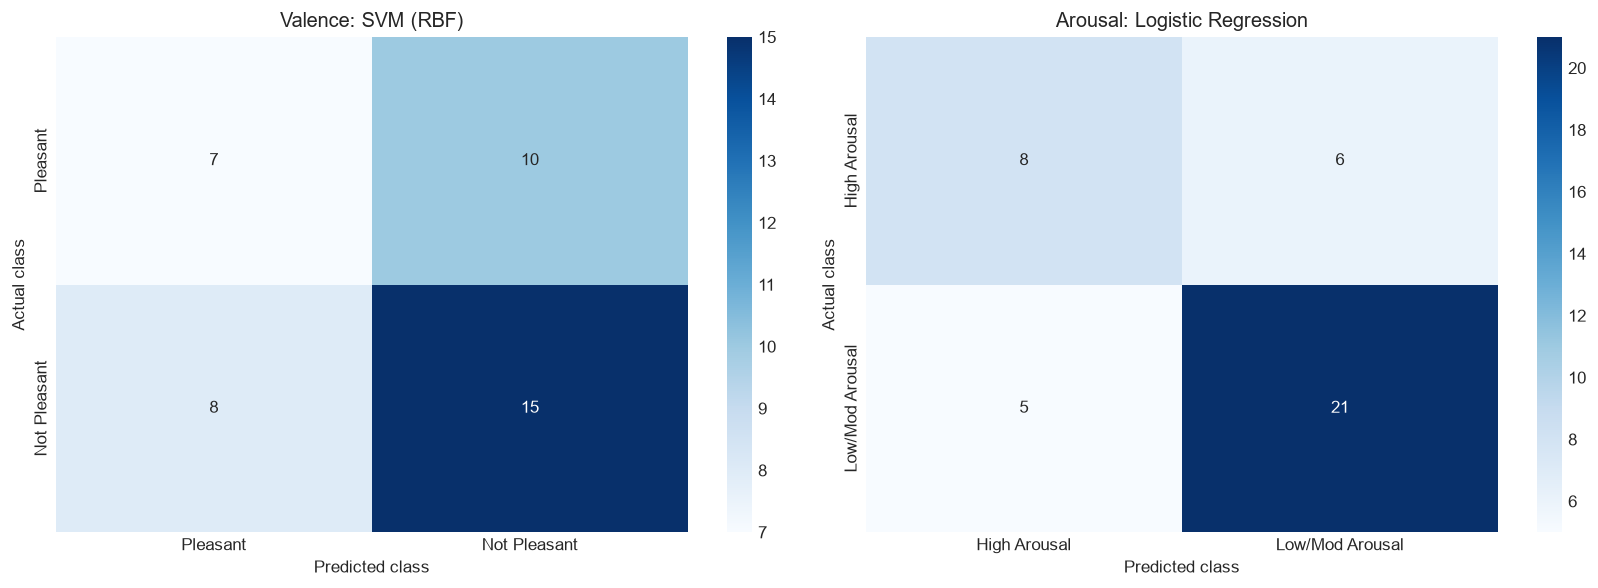

,Feature,Held-out Permutation Importance
70,mfcc_10_mean,0.025068
61,mfcc_delta_8_std,0.024762
58,mfcc_8_mean,0.023111
4,f0_min,0.022430
59,mfcc_8_std,0.021460
28,mfcc_3_mean,0.021460
74,mfcc_delta2_10_mean,0.018159
31,mfcc_delta_3_std,0.017974
25,mfcc_delta_2_std,0.016238
29,mfcc_3_std,0.015700


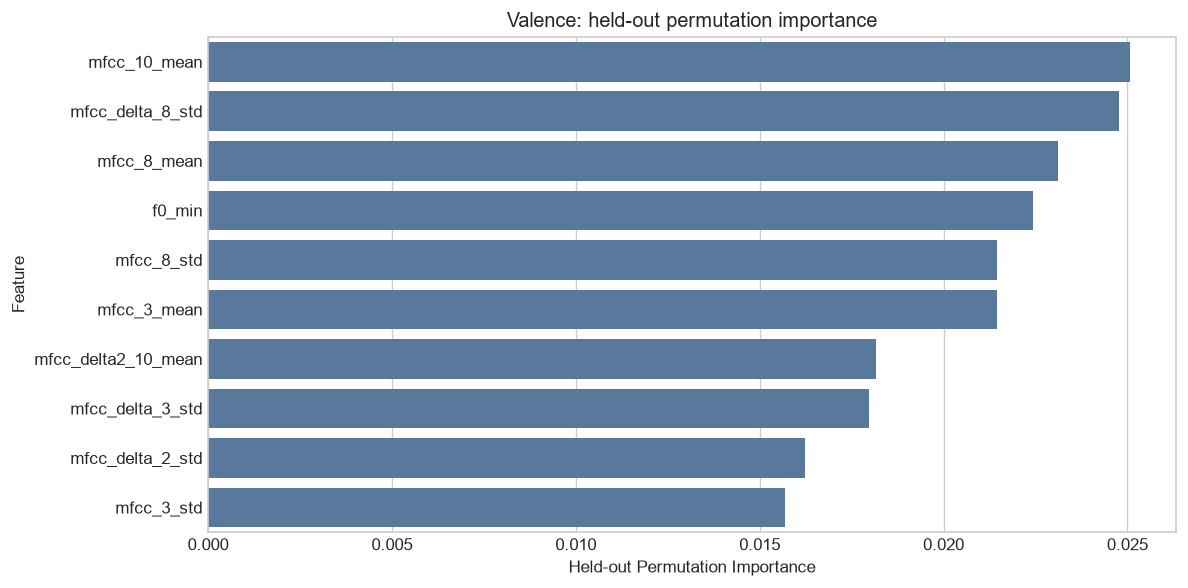

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (target, result) in zip(axes, evaluations.items()):
    labels = targets[target][1]
    sns.heatmap(result['matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f"{target}: {result['best']['Model']}")
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('Actual class')
    display(Markdown(f'#### {target}: pooled out-of-fold classification report'))
    display(result['report'].round(4))
plt.tight_layout()
plt.show()

y = targets['Valence'][0]
best_model = models[evaluations['Valence']['best']['Model']]
fold_importances = []
for fold_number, (train, test) in enumerate(splits_by_target['Valence']):
    fitted = clone(best_model).fit(X.iloc[train], y[train])
    importance = permutation_importance(fitted, X.iloc[test], y[test], scoring='f1_macro',
                                       n_repeats=20, random_state=42 + fold_number, n_jobs=1)
    fold_importances.append(importance.importances_mean)
top_features = pd.DataFrame({'Feature': feature_cols,
    'Held-out Permutation Importance': np.mean(fold_importances, axis=0)
}).sort_values('Held-out Permutation Importance', ascending=False).head(15)
display(top_features)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_features.head(10), x='Held-out Permutation Importance', y='Feature', color='#4C78A8', ax=ax)
ax.set_title('Valence: held-out permutation importance')
plt.tight_layout()
plt.show()


### Step 12: Current findings and export consistency
The following output derives the conclusions from this execution rather than hardcoding a winning model or an accuracy range. It also checks saved export metrics and confusion matrices. A difference can reflect changed inputs, settings, or library versions; do not silently mix different runs. Regenerate exports using `export_audio_outputs.py` when adopting a new run.

Limitations: a small sample with 94 predictors, one year level and one session, incomplete recording documentation, binary grouping of original ratings, and selection/evaluation on the same folds. Neither the overall experiment nor the descriptive same-word analysis establishes reliable affect recognition for new students. The separately saved inference models are not retrained by this notebook.

In [12]:
print('RQ1: valence distribution')
display(df_meta['Valence_Label'].value_counts().rename('Count').to_frame())
print('RQ1: arousal rating distribution')
display(df_meta['Arousal_Score'].value_counts().sort_index().rename('Count').to_frame())
print('RQ2: class activity by valence (descriptive, not causal)')
display(pd.crosstab(df_meta['Class Activity'], df_meta['Valence_Label']))
print(f"Year levels represented: {df_meta['Year Level'].nunique()}; sessions: {df_meta['Session'].nunique()}.")
print('RQ3: acoustic means are descriptive; overlapping distributions do not establish significant effects.')
print(f'Exact Kapoy subset: {len(df_kapoy)} observations; no separate same-word classifier validated.')

for target, result in evaluations.items():
    best = result['best']
    baseline = result['comparison'].set_index('Model').loc['Dummy (Most Frequent)']
    delta = best['Accuracy Mean'] - baseline['Accuracy Mean']
    print(f"RQ4/RQ5 {target}: {best['Model']} leads by mean macro F1 = {best['Macro F1 Mean']:.3f}; "
          f"accuracy = {best['Accuracy Mean']:.1%}, baseline = {baseline['Accuracy Mean']:.1%}, "
          f"difference = {delta * 100:+.1f} percentage points.")

for target, comparison_file, matrix_file in [
    ('Valence', '11_model_comparison.csv', '12_confusion_matrix.csv'),
    ('Arousal', '15_arousal_model_comparison.csv', '16_arousal_confusion_matrix.csv')]:
    saved_path = Path('audio_outputs/tables') / comparison_file
    if not saved_path.exists():
        print(target, 'saved export unavailable; no comparison performed.')
        continue
    old = pd.read_csv(saved_path).set_index('Model')
    current = evaluations[target]['comparison'].set_index('Model')
    differences = []
    for model in current.index:
        for metric in current.columns:
            if model not in old.index or metric not in old.columns:
                differences.append({'Model': model, 'Metric': metric, 'Saved': np.nan, 'Current': current.loc[model, metric]})
            elif not np.isclose(current.loc[model, metric], old.loc[model, metric], rtol=1e-8, atol=1e-10):
                differences.append({'Model': model, 'Metric': metric, 'Saved': old.loc[model, metric], 'Current': current.loc[model, metric]})
    print(f'{target}: {len(differences)} metric differences from saved export.')
    if differences:
        display(pd.DataFrame(differences))
    saved_matrix = pd.read_csv(Path('audio_outputs/tables') / matrix_file, index_col=0)
    labels = targets[target][1]
    assert list(saved_matrix.index) == labels and list(saved_matrix.columns) == labels
    print('Confusion matrix matches saved export:', np.array_equal(saved_matrix.to_numpy(), evaluations[target]['matrix']))


RQ1: valence distribution


,Count
Valence_Label,
Pleasant,17
Neutral,13
Unpleasant,10


RQ1: arousal rating distribution


,Count
Arousal_Score,
1,3
2,10
3,13
4,14


RQ2: class activity by valence (descriptive, not causal)


...

Year levels represented: 1; sessions: 1.
RQ3: acoustic means are descriptive; overlapping distributions do not establish significant effects.
Exact Kapoy subset: 20 observations; no separate same-word classifier validated.
RQ4/RQ5 Valence: SVM (RBF) leads by mean macro F1 = 0.522; accuracy = 55.0%, baseline = 57.5%, difference = -2.5 percentage points.
RQ4/RQ5 Arousal: Logistic Regression leads by mean macro F1 = 0.662; accuracy = 72.5%, baseline = 65.0%, difference = +7.5 percentage points.
Valence: 6 metric differences from saved export.


,Model,Metric,Saved,Current
0,Random Forest,Accuracy SD,0.055902,0.104583
1,Random Forest,Balanced Accuracy Mean,0.505000,0.518333
2,Random Forest,Macro F1 Mean,0.466061,0.480635
3,Random Forest,Macro F1 SD,0.084098,0.135612
4,Random Forest,Macro Precision Mean,0.514286,0.508810
5,Random Forest,Macro Recall Mean,0.505000,0.518333


Confusion matrix matches saved export: True
Arousal: 14 metric differences from saved export.


,Model,Metric,Saved,Current
0,Random Forest,Accuracy Mean,0.700000,0.600000
1,Random Forest,Accuracy SD,0.209165,0.055902
2,Random Forest,Balanced Accuracy Mean,0.626667,0.590000
3,Random Forest,Macro F1 Mean,0.626667,0.566407
4,Random Forest,Macro F1 SD,0.252102,0.062261
5,Random Forest,Macro Precision Mean,0.702857,0.598333
6,Random Forest,Macro Recall Mean,0.626667,0.590000
7,Gradient Boosting,Accuracy Mean,0.600000,0.575000
8,Gradient Boosting,Accuracy SD,0.240442,0.243670
9,Gradient Boosting,Balanced Accuracy Mean,0.590000,0.573333


Confusion matrix matches saved export: True
